In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Dataset 4_2

## S/ SMOTE

In [ ]:
# -------- 1) Carregar dados --------
from pathlib import Path

candidate_files = [Path.cwd() / "data4_2.csv", Path.cwd() / "Final" / "data4_2.csv"]
csv_path = next((path for path in candidate_files if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Não encontrei 'data4_2.csv' na pasta atual nem em 'Final'.")

df4_2 = pd.read_csv(csv_path)
print(f"Dataset carregado de: {csv_path}")

In [ ]:
# -------- 2) Definir target, drops e features --------
target4_2 = "SECClasS_Code_Ss_2_encode"
drop_cols4_2 = ["ElementID", "source", "is_rare_class", "SECClasS_Code_Ss_2"]

features4_2 = [
    "Volume", "Area", "Length", "Height", "Thickness/Width", "Base_offset", "Top_offset",
    "Number_of_Faces", "Bounding_Box_Width", "Bounding_Box_Height", "Bounding_Box_Depth",
    "Centroid_X", "Centroid_Y", "Centroid_Z", "Orientation_Angle", "Curvature",
    "Category_Curtain Panels", "Category_Doors", "Category_Floors", "Category_Roofs",
    "Category_Stairs", "Category_Structural Columns", "Category_Structural Foundations",
    "Category_Structural Framing", "Category_Walls", "Category_Windows",
    "load_bearing_status_binary"
]

In [ ]:
# -------- 3) Preparar X e y --------
df_model = df4_2.drop(columns=drop_cols4_2, errors="ignore")
X = df_model[features4_2].copy()
y = df_model[target4_2].copy()

In [ ]:
# -------- 4) Train/Test Split --------
X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns, index=X_test.index)

# Imputar X completo para usar na Validação Cruzada (CV)
X = pd.DataFrame(imputer.transform(X), columns=X.columns, index=X.index)

labels_sorted = np.sort(pd.unique(y))

In [ ]:
# ---------- 1) Modelos: SEM e COM SMOTE ----------
# Hiperparâmetros inicials razoáveis (ajusta se quiseres)
xgb_params = dict(
    objective="multi:softprob",        # multiclasse
    eval_metric="mlogloss",            # evita warnings; métrica interna
    tree_method="hist",                # treino mais rápido
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    importance_type="gain",            # p/ feature_importances_
)

# 1a) SEM SMOTE
xgb_no = XGBClassifier(**xgb_params)
xgb_no.fit(X_train, y_train)
pred_no = xgb_no.predict(X_test)

# 1b) COM SMOTE (aplicado só no treino) — k_neighbors=3 p/ reduzir risco em classes muito pequenas
pipe_smote = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42, k_neighbors=3)),
    ("xgb",   XGBClassifier(**xgb_params)),
])
pipe_smote.fit(X_train, y_train)
pred_sm = pipe_smote.predict(X_test)

In [ ]:
# ---------- 2) Métricas no TESTE ----------
def print_test_metrics(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== TESTE — {tag} ===")
    print(f"Accuracy:         {acc:.4f}")
    print(f"Balanced Accuracy:{bal:.4f}")
    print(f"F1-macro:         {f1m:.4f}")
    print(f"F1-weighted:      {f1w:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    return acc, bal, f1m, f1w

acc_no, bal_no, f1m_no, f1w_no = print_test_metrics(y_test, pred_no, "XGBoost (SEM SMOTE)")
acc_sm, bal_sm, f1m_sm, f1w_sm = print_test_metrics(y_test, pred_sm, "XGBoost (COM SMOTE)")


=== TESTE — XGBoost (SEM SMOTE) ===
Accuracy:         0.9830
Balanced Accuracy:0.9665
F1-macro:         0.9733
F1-weighted:      0.9827

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        40
           1     0.9889    0.9944    0.9916       358
           2     0.9973    0.9893    0.9933       374
           3     0.9910    0.9910    0.9910       335
           4     0.9463    0.9724    0.9592       145
           5     0.9753    0.9693    0.9723       163
           6     0.9598    0.9808    0.9702       365
           7     1.0000    1.0000    1.0000         9
           8     0.9848    1.0000    0.9924        65
           9     1.0000    1.0000    1.0000       386
          10     0.9545    0.9130    0.9333        46
          11     1.0000    1.0000    1.0000        10
          12     1.0000    1.0000    1.0000        68
          13     1.0000    1.0000    1.0000        32
          14     1.0000    1

In [ ]:
import sys
from pathlib import Path

candidate_module_dirs = [Path.cwd(), Path.cwd() / "Final"]
for module_dir in candidate_module_dirs:
    if (module_dir / "inference_artifacts.py").exists():
        module_dir_str = str(module_dir)
        if module_dir_str not in sys.path:
            sys.path.insert(0, module_dir_str)

from inference_artifacts import ensure_artifact_dirs, save_model_bundle

dirs = ensure_artifact_dirs()
xgb_no_path = save_model_bundle(
    name="xgboost4_2_sem_smote",
    estimator=xgb_no,
    imputer=imputer,
    features=X.columns,
    target_column=target4_2,
    class_labels=labels_sorted,
    metrics={"accuracy": acc_no, "balanced_accuracy": bal_no, "f1_macro": f1m_no, "f1_weighted": f1w_no},
    metadata={"algorithm": "XGBClassifier", "dataset": "data4_2.csv", "variant": "sem_smote", "source_notebook": "xgboost4_2.ipynb"},
)
xgb_sm_path = save_model_bundle(
    name="xgboost4_2_com_smote",
    estimator=pipe_smote,
    imputer=imputer,
    features=X.columns,
    target_column=target4_2,
    class_labels=labels_sorted,
    metrics={"accuracy": acc_sm, "balanced_accuracy": bal_sm, "f1_macro": f1m_sm, "f1_weighted": f1w_sm},
    metadata={"algorithm": "XGBClassifier", "dataset": "data4_2.csv", "variant": "com_smote", "source_notebook": "xgboost4_2.ipynb"},
)

print(f"Modelo guardado em: {xgb_no_path}")
print(f"Modelo guardado em: {xgb_sm_path}")

<Figure size 640x480 with 0 Axes>

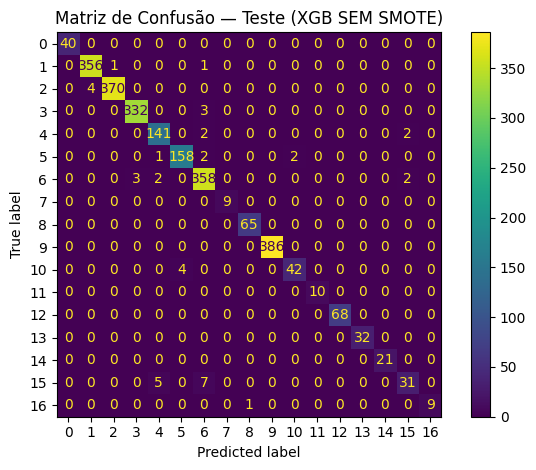

<Figure size 640x480 with 0 Axes>

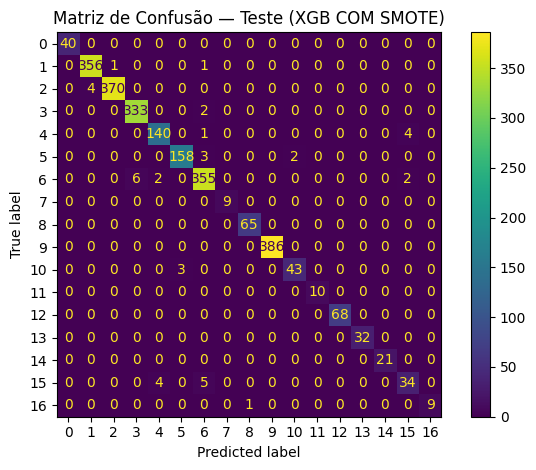

In [ ]:
# ---------- 3) Matrizes de confusão (TESTE) ----------
plt.figure()
cm_no = confusion_matrix(y_test, pred_no, labels=labels_sorted)
ConfusionMatrixDisplay(confusion_matrix=cm_no, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — Teste (XGB SEM SMOTE)")
plt.tight_layout(); plt.show()

plt.figure()
cm_sm = confusion_matrix(y_test, pred_sm, labels=labels_sorted)
ConfusionMatrixDisplay(confusion_matrix=cm_sm, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — Teste (XGB COM SMOTE)")
plt.tight_layout(); plt.show()


Top 10 features — XGB SEM SMOTE:
                            Feature  Importance
21      Category_Structural Columns    0.220095
23      Category_Structural Framing    0.202338
22  Category_Structural Foundations    0.128532
24                   Category_Walls    0.082902
18                  Category_Floors    0.079260
20                  Category_Stairs    0.055584
4                   Thickness/Width    0.034799
26       load_bearing_status_binary    0.027558
3                            Height    0.021598
7                   Number_of_Faces    0.018893

Top 10 features — XGB COM SMOTE:
                            Feature  Importance
25                 Category_Windows    0.282739
17                   Category_Doors    0.212228
20                  Category_Stairs    0.102365
22  Category_Structural Foundations    0.089319
21      Category_Structural Columns    0.077251
23      Category_Structural Framing    0.063280
18                  Category_Floors    0.052647
24                  

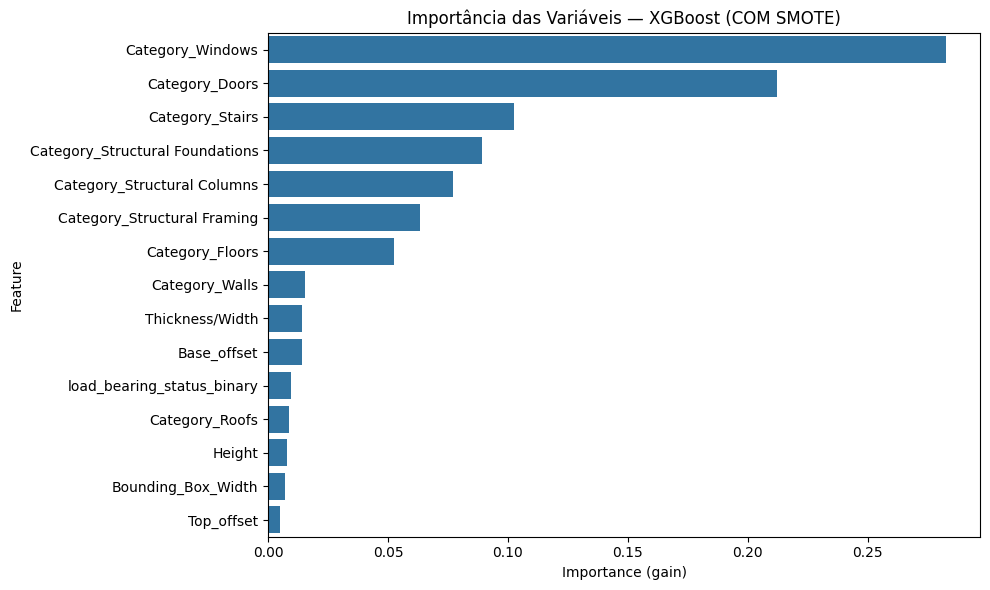

In [ ]:
# ---------- 4) Importância das variáveis ----------
feature_names = getattr(X, "columns", [f"feat_{i}" for i in range(X.shape[1])])

# SEM SMOTE
imp_no = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_no.feature_importances_
}).sort_values("Importance", ascending=False)

# COM SMOTE (pegar o estimador dentro do pipeline)
xgb_sm_est = pipe_smote.named_steps["xgb"]
imp_sm = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_sm_est.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 10 features — XGB SEM SMOTE:")
print(imp_no.head(10))
print("\nTop 10 features — XGB COM SMOTE:")
print(imp_sm.head(10))

# Gráfico Top-15 COM SMOTE (troca para imp_no se preferires)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_sm.head(15))
plt.title("Importância das Variáveis — XGBoost (COM SMOTE)")
plt.xlabel("Importance (gain)"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()

In [ ]:
# ---------- 5) Validação Cruzada (5-fold) com múltiplas métricas ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorings = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

# 5a) SEM SMOTE
xgb_cv = XGBClassifier(**xgb_params)
cv_no = cross_validate(xgb_cv, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

# 5b) COM SMOTE (pipeline p/ evitar leakage)
pipe_smote_cv = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42, k_neighbors=3)),
    ("xgb",   XGBClassifier(**xgb_params)),
])
cv_sm = cross_validate(pipe_smote_cv, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

def resumo_cv(nome, res):
    print(f"\n=== CV (5-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f"test_{k}"]
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f}  (min={vals.min():.4f}, max={vals.max():.4f})")

resumo_cv("XGBoost SEM SMOTE", cv_no)
resumo_cv("XGBoost COM SMOTE", cv_sm)


=== CV (5-fold) — XGBoost SEM SMOTE ===
acc         : 0.9823 ± 0.0027  (min=0.9785, max=0.9854)
bal_acc     : 0.9647 ± 0.0094  (min=0.9526, max=0.9751)
f1_macro    : 0.9712 ± 0.0074  (min=0.9615, max=0.9806)
f1_weighted : 0.9821 ± 0.0028  (min=0.9780, max=0.9853)

=== CV (5-fold) — XGBoost COM SMOTE ===
acc         : 0.9819 ± 0.0017  (min=0.9794, max=0.9838)
bal_acc     : 0.9664 ± 0.0095  (min=0.9537, max=0.9764)
f1_macro    : 0.9695 ± 0.0054  (min=0.9631, max=0.9772)
f1_weighted : 0.9818 ± 0.0018  (min=0.9790, max=0.9839)



=== Matriz de Confusão — CV (SEM SMOTE) ===
     0     1     2     3    4    5     6   7    8     9    10  11   12   13  \
0   192     3     2     0    1    0     0   0    0     0    0   0    0    0   
1     0  1780     2     0    3    0     1   0    0     0    0   0    3    0   
2     0    14  1854     0    1    0     0   0    0     0    0   0    0    0   
3     0     0     0  1660    0    0    15   0    0     2    0   0    0    0   
4     0     0     1     0  710    1     4   0    0     0    0   0    0    0   
5     0     0     0     1    3  787     3   0    0     0   23   0    0    0   
6     0     0     0    36    8    3  1771   0    0     0    0   0    0    0   
7     0     0     0     0    0    0     0  44    0     0    0   0    0    0   
8     0     0     0     0    0    0     0   0  324     0    0   0    0    0   
9     0     0     0     0    0    0     0   0    0  1929    0   0    0    0   
10    0     0     0     0    0   16     0   0    0     0  217   0    0    0   
11    0

<Figure size 640x480 with 0 Axes>

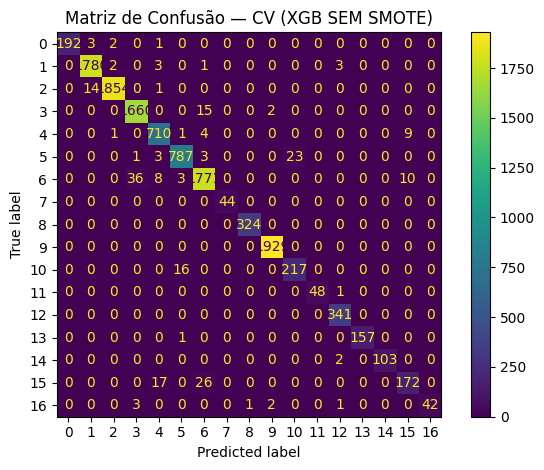

<Figure size 640x480 with 0 Axes>

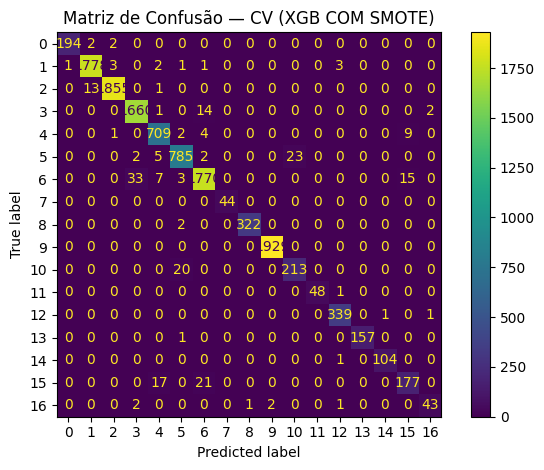

In [ ]:
# ---------- 6) Matrizes de confusão out-of-fold (CV) ----------
y_pred_cv_no = cross_val_predict(xgb_cv, X, y, cv=cv, n_jobs=-1)
y_pred_cv_sm = cross_val_predict(pipe_smote_cv, X, y, cv=cv, n_jobs=-1)

cm_cv_no = confusion_matrix(y, y_pred_cv_no, labels=labels_sorted)
cm_cv_sm = confusion_matrix(y, y_pred_cv_sm, labels=labels_sorted)

print("\n=== Matriz de Confusão — CV (SEM SMOTE) ===")
print(pd.DataFrame(cm_cv_no, index=labels_sorted, columns=labels_sorted))

print("\n=== Matriz de Confusão — CV (COM SMOTE) ===")
print(pd.DataFrame(cm_cv_sm, index=labels_sorted, columns=labels_sorted))

# Visualização (opcional)
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_no, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (XGB SEM SMOTE)")
plt.tight_layout(); plt.show()

plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_sm, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (XGB COM SMOTE)")
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# EXPORTAÇÃO DO MODELO PARA INFERÊNCIA
# ============================================================
# Guarda o encoder e os dois modelos treinados.
# Na inferência, os dados já chegam preparados pelo pipeline
# de data preparation, por isso não é necessário guardar o imputer.
#
# Ficheiros gerados (pasta Final/models/):
#   encoder_4_2.pkl   — LabelEncoder: converte número de volta para código SEC
#   xgb_4_2.pkl       — XGBoost treinado SEM SMOTE
#   xgb_sm_4_2.pkl    — XGBoost treinado COM SMOTE
# ============================================================

import joblib
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# ---------- Pasta de destino ----------
models_dir = csv_path.parent / "models"
models_dir.mkdir(exist_ok=True)

# ---------- Encoder do target ----------
encoder = LabelEncoder()
encoder.fit(df4_2["SECClasS_Code_Ss_2"].astype(str))
joblib.dump(encoder, models_dir / "encoder_4_2.pkl")
print(f"[OK] Encoder guardado → {models_dir / 'encoder_4_2.pkl'}")

# ---------- Modelos ----------
joblib.dump(xgb_no, models_dir / "xgb_4_2.pkl")
print(f"[OK] XGBoost (SEM SMOTE) guardado → {models_dir / 'xgb_4_2.pkl'}")

joblib.dump(pipe_smote, models_dir / "xgb_sm_4_2.pkl")
print(f"[OK] XGBoost (COM SMOTE) guardado → {models_dir / 'xgb_sm_4_2.pkl'}")

print("\n=== Exportação concluída! ===")
print("Para fazer inferência em dados novos:")
print("  import joblib")
print("  encoder = joblib.load('Final/models/encoder_4_2.pkl')")
print("  model   = joblib.load('Final/models/xgb_4_2.pkl')  # ou xgb_sm_4_2.pkl")
print("  pred    = encoder.inverse_transform(model.predict(X_new))")